# Tensorflow & Keras

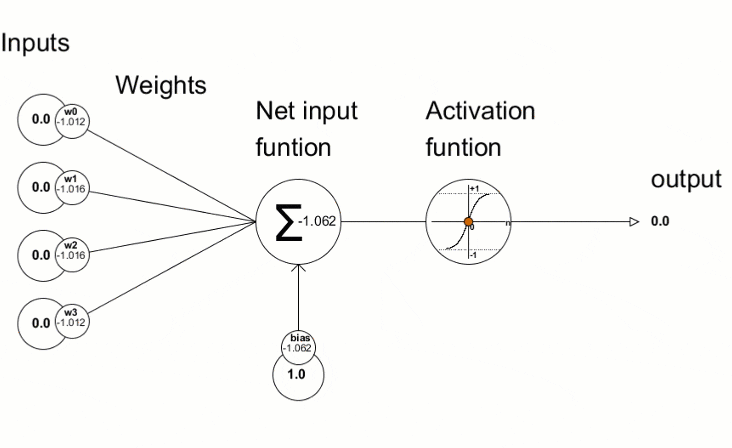

Conceptos: A diferencia del Descenso Gradiente visto en el Módulo 4 hay 3 variantes de cómo seleccionar los datos: 
1. Descenso Gradiente Estocástica: Calcula el error para cada observación y actualiza. También se le conoce como *Online* ML Algorithm
2. Descenso de Gradiente Batch: Calcula para cada observación pero actualiza los parámetros hasta que acaba todas las observaciones. Un ciclo de esto se llama Epoch. 
3. Descenso de Gradiente Mini-Batch: Divide El Training Data Set en pequeños Batches que se usan para actualizar los coeficientes .Se suman los gradientes para cada mini-batch. 

En la imagen siguiente hay al menos diez metodologías para encontrar el conjunto óptimo de pesos: 

# Descenso de Gradiente

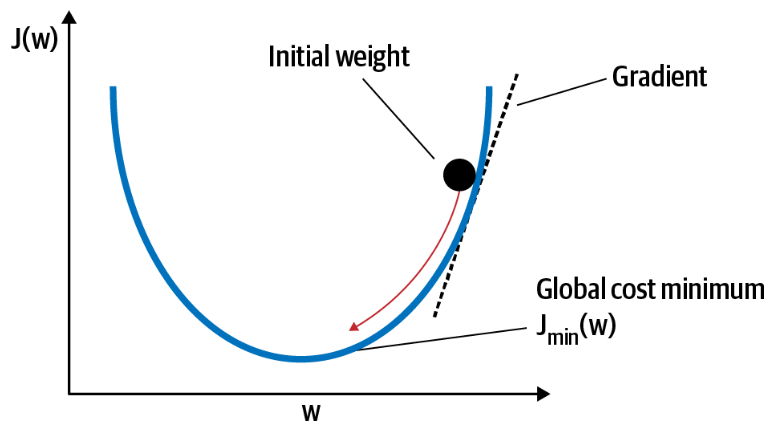

Modelos como la regresión lineal y Ridge sí tienen soluciones analíticas. Sin embargo, la búsqueda de soluciones analíticas trae consigo algunos problemas: 
1. Podría no existir para modelos más complejos
2. Calcular la solución analítica podría volverse un problema no factible dada la gran cantidad de datos. 

Para encontrar $\theta^*$ dada una función objetivo $J(\theta^* | X ^{train})$ derivable, introducir un modelo de descenso de gradiente. 

Para una función $f(x)$, definimos la derivada de $f$ como

$$
    \frac{d}{dx} f(x) := \lim_{h\to0}\frac{f(x + h) - f(x)}{h}
$$

# Efecto simple de una derivada

En machine learning, interpretamos la derivada como una **dirección**, que indica hacia donde $f$ crece más. La idea detrás de **Descenso de Gradiente (Gradient Descent)** es minimizar $f(x)$ tomando pequeños pasos hacia la dirección que hace que $f(x)$ sea lo más pequeña posible. 

¿Cómo?

1. Seleccionamos una posición $x_0$ inicial 
2. Iterando $n$ veces: 
    1. Estando en $x_0$, calculamos la dirección donde $f(x)$ **decrece** lo más posible. 
    2. Actualizamos $x_0$ tomando pequeños pasos en la dirección encontrada

Para una función `f` con input y output. Calculamos un mínimo local por medio de descenso de gradiente de la siguiente forma: 
```python
x=x0
for i in range(n):
    x=x-alpha*df(x)

```
Donde: 
* `df(x)` es una función que calcula la derivada de `f` evaluada en `x`. 
* $\alpha$, es el *learning rate*, es un hiperparámetro que controla el tamaño del paso hacia la dirección de mayor descenso. 



### Ejercicio
Considerando la función $f(x)=(x-3)^2+1$
* $\frac{d}{dx}f(x)$=2(x-3)
* `x0=5`
* `n=20`

Calcular por medio de descenso de gradiente el valor de `x` después de `n` pasos si `alpha=.01`, `alpha=.2`, `alpha=2`. ¿Qué valores de `x` llegamos para cada alpha?

In [ ]:
#queremos ver donde se minimiza la función
#f(x)=(x-3)**2 + 1

#Se minimiza la derivada igual a cero y despejando x
#derivada: 2(x-3)==0
#x=3

In [ ]:
#Vamos a ver cómo llegar a la solución de arriba por otro camino
#descenso de gradiente

In [1]:
alfa=.01
def f(x):
    return (x-3)**2+1

In [2]:
def deriv(x,h=1e-6): return (f(x+h)-f(x))/h

In [3]:
def fn_gradiente_descenso(x0=5,n=20,alfa=.01):
    x=x0
    for i in range(n):
        x=x-alfa*deriv(x)
    return x

In [5]:
fn_gradiente_descenso(x0=5,n=20,alfa=.2)

3.000072623183243

In [6]:
fn_gradiente_descenso(x0=5,n=20,alfa=.01)

4.335215777254149

In [7]:
fn_gradiente_descenso(x0=5,n=20,alfa=2)

5902033590.153048

In [9]:
alfa=2

In [10]:
5-alfa*deriv(5)

-3.000002001296025

In [12]:
-3.000002001296025-alfa*deriv(-3.000002001296025)

21.000004006144763

#### ¿Cómo elegimos alfa?
Un $\alpha$ muy pequeña hace que el modelo toma muchas iteraciones para llegar a un mínimo (undershoot); por el contrario ,un $\alpha$ muy grande nos hace diverger del óptimo (overshoot). 

En general, para una función objetivo $J(\theta)$, donde $\theta$ es un vector con $m$ entradas, calculamos el **gradiente** de $J$: 

$$
    \nabla J(\theta) = \begin{bmatrix}
                        \frac{\partial}{\partial \theta_0}J(\theta)\\
                        \frac{\partial}{\partial \theta_1}J(\theta)\\
                        \vdots \\
                        \frac{\partial}{\partial \theta_m}J(\theta)\\
                       \end{bmatrix}
$$

En este sentido, un paso en gradient descent constituye actualizar cada entrada del vector $\nabla J(\theta)$ antes de pasar a una siguiente iteración.

# Ejemplo: Regresión Lineal Generalizada
Para el modelo de regresión lineal generalizada:

$\hat y = w_0 + w_1 x_1 + w_2 x_2 + \ldots + w_m x_m = {\bf w}^T{\bf x}$

Con
$$
    J(w_0, w_1, \ldots, w_m) = \frac{1}{2n}\sum_{i=1}^n\left(\hat y_i - y_i\right)^2
$$

Se puede demostrar que

$$
    \frac{\partial}{\partial \theta_j} = \begin{cases}
        \frac{1}{n}\sum_{i=1}^n\left(\hat y_i - y\right)x_j^{(i)} & j \neq 0 \\
        \frac{1}{n}\sum_{i=1}^n\left(\hat y_i - y\right) & j = 0 \\
    \end{cases}
$$

El pseudocódigo de gradient descent sería.

Asignar $\theta = \vec{0}$

Para cada $n=1,\ldots, nrounds${

Para cada $j=1,\ldots, m${

$\theta_j = \theta_j - \frac{\alpha}{n}\sum_{i=1}^n\left(\hat y_i - y\right)x_j^{(i)}$

    }

}

In [13]:
21.000004006144763-alfa*deriv(21.000004006144763)

-51.000014115653585

https://www.youtube.com/watch?v=MD2fYip6QsQ

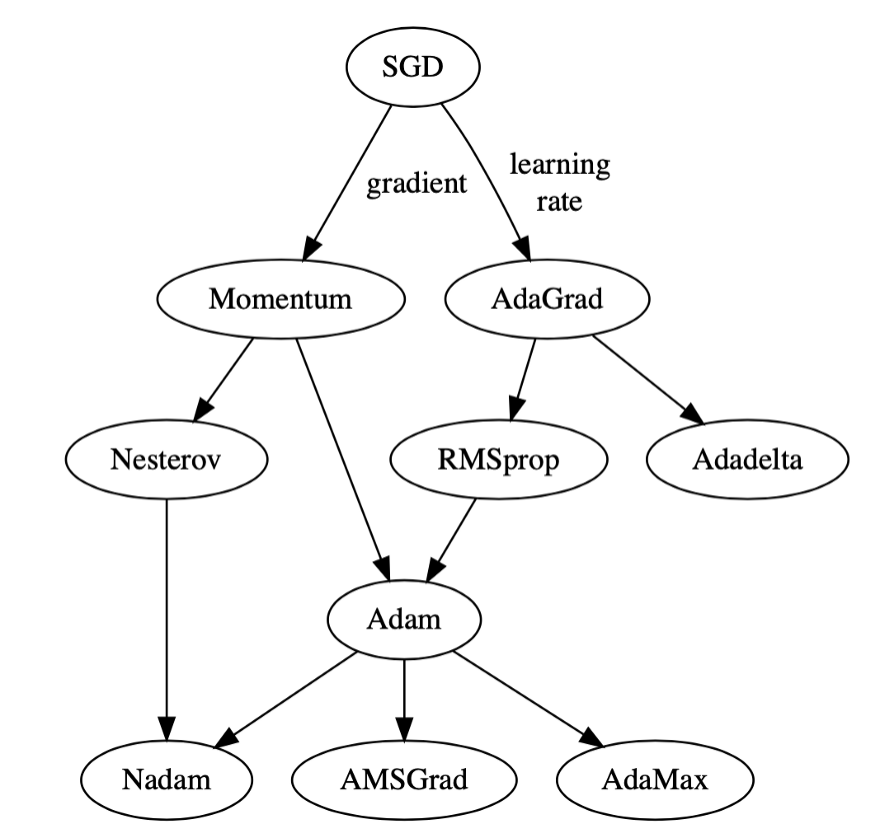

Deep Learning recomienda Mini-Batch. Pequeños valores de Batch convergen más rápido (trade-off de tener más ruido en el proceso). Grandes valores de Batch se tardan en coverger pero son más precisos. Batch size que se recomienda es 32. 

# Cargando Tensorflow

In [8]:
#pip install tensorflow
import tensorflow as tf

In [9]:
tf.__version__

'2.10.0'

# Redes Neuronales para Clasificación

In [10]:
from tensorflow.keras.datasets import fashion_mnist

In [11]:
import numpy as np
from numpy.random import seed, choice
import matplotlib.pyplot as plt

In [32]:
(X_train, y_train), (X_test,y_test)=fashion_mnist.load_data()

In [33]:
X_train.shape

(60000, 28, 28)

In [34]:
(X_train/255.0)[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [35]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

In [36]:
X_train[14856] #bolsa

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  44,
        145, 162, 150,  57,   0,   0,   1,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 125, 161,
         71,  22,  68, 205, 117,   0,   1,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   3,   0,  74, 164,   0,
          0,   0,   0,   0, 162,  64,   0,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   1,   0,   0, 156,  59,   0,
          3,   0,   2,   0,   5, 117,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   3,   0,  39, 150,   0,   0,
          0,   0,   0,   3,   0,  98,  46,   0,   2,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   6,   0,  79, 124,   0,   0,
          0,   0,   0,   3,   0,  74,  87,   0,   3,   0,   0,   0,   0,
          0,   0],
       [  

In [37]:
categories={
    0:"playeras",
    1:"pantalones",
    2:"pullover",
    3:"vestido",
    4: "abrigo",
    5: "sandalias",
    6:"camisa",
    7:"tennis",
    8:"bolsa",
    9:"Botas",
}

In [38]:
N, *_=y_train.shape

In [39]:
N


60000

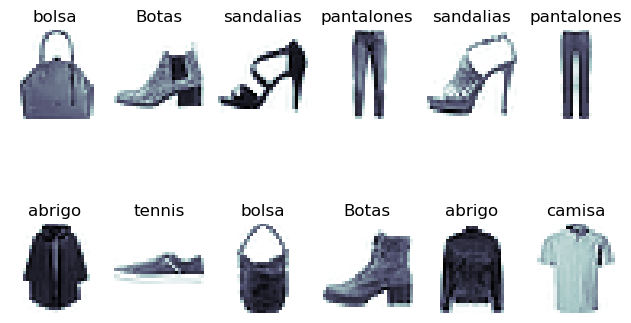

In [40]:
seed(314)
indices=np.arange(N,dtype=int)
test_ix=choice(indices,12)#12 imágenes al azar
fig, ax=plt.subplots(2,6)
ax=ax.ravel()
for axi,ix in zip(ax,test_ix):
    axi.imshow(X_train[ix],cmap="bone_r")
    cat=categories[y_train[ix]]
    axi.set_title(cat)
    axi.axis("off")
plt.tight_layout()

In [41]:
X_train.shape

(60000, 28, 28)

In [42]:
X_train.shape[0]

60000

In [43]:
X_train=X_train.reshape((X_train.shape[0],28,28,1))#agregamos una dimensión
X_test=X_test.reshape((X_test.shape[0],28,28,1))#agregamos una dimensión


In [44]:
X_train.shape

(60000, 28, 28, 1)

In [45]:
X_train[0]

array([[[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0]],

       [[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0]],

       [[  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
        [  0],
      

In [46]:
y_train

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [47]:
#One Hot Encoder
y_train=tf.keras.utils.to_categorical(y_train)
y_test=tf.keras.utils.to_categorical(y_test)

In [48]:
y_train

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [49]:
y_train.shape

(60000, 10)

### Función para descargar datos

In [50]:
def cargar_datos():
    #Descargar datos
    (X_train, y_train), (X_test,y_test)=fashion_mnist.load_data()
    #le hacemos un reshape par tenerlo vectorizado (luego estandarizar)
    X_train=X_train.reshape((X_train.shape[0],28,28,1))#agregamos una dimensión
    X_test=X_test.reshape((X_test.shape[0],28,28,1))#agregamos una dimensión
    
    #One Hot Encoder
    y_train=tf.keras.utils.to_categorical(y_train)
    y_test=tf.keras.utils.to_categorical(y_test)
    
    return X_train, y_train, X_test, y_test

In [51]:
trainX, trainY, testX, testY=cargar_datos()

In [52]:
trainY

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

### Normalizar datos

In [53]:
trainX.shape

(60000, 28, 28, 1)

In [54]:
trainX

array([[[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]]],


       [[[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        [[0],
         [0],
         [0],
         ...,
         [0],
         [0],
         [0]],

        ...,

        [[0],
         [0],
         [0],
         ...,
         [0],


In [55]:
trainX.min()

0

In [56]:
trainX.max()

255

In [57]:
trainX.astype("float32")/255.0

array([[[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]]],


       [[[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        [[0.],
         [0.],
         [0.],
         ...,
         [0.],
         [0.],
         [0.]],

        ...,

        [[0.],
 

In [59]:
def escalar_imagen(train,test):
    #convertir a flotatntes y normalizar en el rango 0-1
    maximo=train.max()
    
    train_norm=train.astype("float32")/maximo
    test_norm=test.astype("float32")/maximo
    
    #regrese las imágenes normalizadas
    
    return train_norm, test_norm
    

In [60]:
trainX_std, testX_std=escalar_imagen(trainX,testX)

In [61]:
trainX_std[0]

array([[[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ],
        

In [62]:
trainX_std.shape

(60000, 28, 28, 1)

# Una primer Feed-Forward Neural Network

In [63]:
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Input, Dense, Flatten

## Paso 1: Definiendo la Arquitectura de la Red


In [40]:
28*28

784

In [ ]:
#original (28 filas y 28 columnas)
1   2   3  ...28
29  30  31... 56
57  58 .......84
.....
...

      ...     756
757           784

In [ ]:
#flatten (1x784)
1 2 3 4...28 29 30...56 57 ...756 757 ...784

In [64]:
#El método que vamos a ver a continuacón define la Red en Keras Anidando
#Capas
Xin=Input(shape=(28,28,1))
#lo pasamos a una dimensión, cada imagen la pasamon a un flatten
#El flatten va a convertir una imagen de 28x28(matriz) a 784x1(fila)

X=Flatten()(Xin)
X=Dense(350,activation="relu")(X) #Anidamos (X), agregando info
X=Dense(100,activation="relu")(X)
X=Dense(10,activation="softmax")(X)
model=Model(inputs=Xin,outputs=X)

In [65]:
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 350)               274750    
                                                                 
 dense_1 (Dense)             (None, 100)               35100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 310,860
Trainable params: 310,860
Non-trainable params: 0
_________________________________________________________________


In [51]:
#flatten. Imágenes se pasan a un vector
28*28

784

In [52]:
#Dense= Que la neurona está totalmente conectada

#Primera Capa: 
#Pesos/Fleas/Coeficientes/Parámetros que se generan para cada neurona de la capa oculta. 


784 #se concectan los 784 inputs a cada una de las 350 neuronas de la primer capa oculta
784*350
#Además tiene un bias que su input es 1 (ese input se conecta con 350 neuronas=1*350=350)
#Al final, el número de coeficientes de la capa input a la primer capa oculta son: 
784*350+ 350



274750

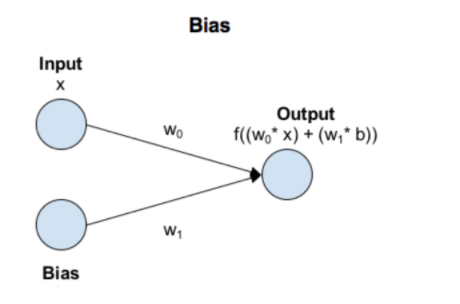

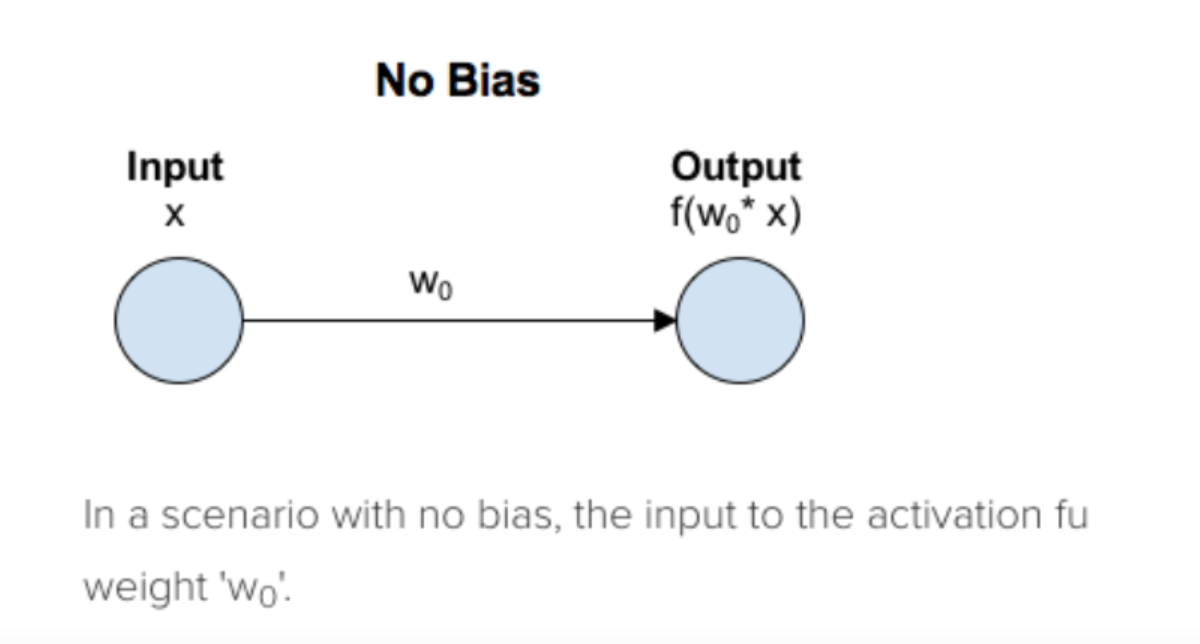

In [53]:
#Segunda Cpa Oculta. 
#350 neuronas que se conectan a 100 neuronas (35,000 coeficientes).  Además, hay que 
#agregarle las 100 neuronas por el tema del Bias. 
350*100+100

35100

In [54]:
#Capa de Salida
#100 neuronas que se conectan a las últimas 10 neuronas de la capa de salida. 
#(100x10) + 10 del Bias. 
100*10+10

1010

In [55]:
#en total se tienen 
274750+35100+1010

310860

# Otra forma de escribir el modelo es usando `Sequential`  para la Red es:

In [56]:
model=Sequential()
model.add(Flatten(input_shape=(28,28,1)))
model.add(Dense(350,activation="relu"))
model.add(Dense(100,activation="relu"))
model.add(Dense(10,activation="softmax"))


In [57]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 350)               274750    
                                                                 
 dense_4 (Dense)             (None, 100)               35100     
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 310,860
Trainable params: 310,860
Non-trainable params: 0
_________________________________________________________________


# Scikit_Learn Wrappers (Muy útil porque les conecta Keras con ScikitLearn)

In [58]:
from tensorflow.keras.wrappers.scikit_learn import KerasClassifier

In [59]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

In [60]:
from tensorflow.keras.optimizers import SGD

In [61]:
def define_model2():
    model=Sequential()
    model.add(Flatten(input_shape=(28,28,1)))
    model.add(Dense(350,activation="relu"))
    model.add(Dense(100,activation="relu"))
    model.add(Dense(10,activation="softmax"))
    opt=SGD(learning_rate=.01)
    model.compile(optimizer=opt,
                 loss="categorical_crossentropy",
                 metrics=["accuracy"])
    return model

In [62]:
modelo=define_model2()

In [63]:
modelo.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_2 (Flatten)         (None, 784)               0         
                                                                 
 dense_6 (Dense)             (None, 350)               274750    
                                                                 
 dense_7 (Dense)             (None, 100)               35100     
                                                                 
 dense_8 (Dense)             (None, 10)                1010      
                                                                 
Total params: 310,860
Trainable params: 310,860
Non-trainable params: 0
_________________________________________________________________


In [64]:
#Ventaja del Wrapper es que el Elemento de keras se convierte en un elemento 
#de Scikit-learn
#se llama sin paréntesis la "build_fn"
clf_1=KerasClassifier(build_fn=define_model2,epochs=3,batch_size=30)

/var/folders/7g/xzn81_k552sdfl4wq54ssx080000gn/T/ipykernel_1239/1722900603.py:4: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  clf_1=KerasClassifier(build_fn=define_model2,epochs=3,batch_size=30)


In [65]:
len(trainX)

60000

In [66]:
len(trainX)/30 #2,000 grupos de 30 observacioines

2000.0

In [69]:
clf_1.fit(trainX,trainY)

Epoch 1/3
2000/2000 [==============================] - 2s 1ms/step - loss: 0.6855 - accuracy: 0.7723
Epoch 2/3
2000/2000 [==============================] - 2s 1ms/step - loss: 0.4749 - accuracy: 0.8343
Epoch 3/3
2000/2000 [==============================] - 2s 1ms/step - loss: 0.4308 - accuracy: 0.8490


In [70]:
trainY

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [73]:
#Generar un Pipeline
estimators=[]
estimators.append(
    ("mlp",KerasClassifier(build_fn=define_model2,epochs=3,batch_size=30))
)
pipeline=Pipeline(estimators)




/var/folders/7g/xzn81_k552sdfl4wq54ssx080000gn/T/ipykernel_1239/1675043107.py:5: DeprecationWarning: KerasClassifier is deprecated, use Sci-Keras (https://github.com/adriangb/scikeras) instead. See https://www.adriangb.com/scikeras/stable/migration.html for help migrating.
  ("mlp",KerasClassifier(build_fn=define_model2,epochs=3,batch_size=30))


In [74]:
kfold=KFold(5,shuffle=True,random_state=1)

In [75]:
results=cross_val_score(pipeline,trainX,trainY,cv=kfold)

Epoch 1/3
1600/1600 [==============================] - 2s 1ms/step - loss: 0.7255 - accuracy: 0.7629
Epoch 2/3
1600/1600 [==============================] - 2s 1ms/step - loss: 0.4938 - accuracy: 0.8286
Epoch 3/3
400/400 [==============================] - 0s 631us/step - loss: 0.4310 - accuracy: 0.8494
Epoch 1/3
1600/1600 [==============================] - 2s 1ms/step - loss: 0.7315 - accuracy: 0.7615
Epoch 2/3
1600/1600 [==============================] - 2s 1ms/step - loss: 0.4921 - accuracy: 0.8294
Epoch 3/3
400/400 [==============================] - 0s 581us/step - loss: 0.4203 - accuracy: 0.8534
Epoch 1/3
1600/1600 [==============================] - 2s 1ms/step - loss: 0.7411 - accuracy: 0.7581
Epoch 2/3
1600/1600 [==============================] - 2s 1ms/step - loss: 0.4919 - accuracy: 0.8286
Epoch 3/3
400/400 [==============================] - 0s 615us/step - loss: 0.4409 - accuracy: 0.8505
Epoch 1/3
1600/1600 [==============================] - 2s 1ms/step - loss: 0.7209 - accurac

In [76]:
results

array([0.84941667, 0.85341668, 0.85049999, 0.84833336, 0.84566665])

In [77]:
results.mean()

0.8494666695594788

In [78]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten_1 (Flatten)         (None, 784)               0         
                                                                 
 dense_3 (Dense)             (None, 350)               274750    
                                                                 
 dense_4 (Dense)             (None, 100)               35100     
                                                                 
 dense_5 (Dense)             (None, 10)                1010      
                                                                 
Total params: 310,860
Trainable params: 310,860
Non-trainable params: 0
_________________________________________________________________


# Paso 2: compilando el modelo usando la versión anterior

In [79]:
def define_model():
    #El método que vamos a ver a continuacón define la Red en Keras Anidando
    #Capas
    Xin=Input(shape=(28,28,1))
    #lo pasamos a una dimensión, cada imagen la pasamon a un flatten
    #El flatten va a convertir una imagen de 28x28(matriz) a 784x1(fila)

    X=Flatten()(Xin)
    X=Dense(350,activation="relu")(X) #Anidamos (X), agregando info
    X=Dense(100,activation="relu")(X)
    X=Dense(10,activation="softmax")(X)
    model=Model(inputs=Xin,outputs=X)

    opt=SGD(learning_rate=.01)
    model.compile(optimizer=opt,
                 loss="categorical_crossentropy",
                 metrics=["accuracy"])
    return model

In [80]:
model=define_model()

## Paso 3: Entrenar Modelo


<blockquote class="twitter-tweet"><p lang="en" dir="ltr">Training with large minibatches is bad for your health.<br>More importantly, it&#39;s bad for your test error.<br>Friends dont let friends use minibatches larger than 32. <a href="https://t.co/hxx2rGhIG1">https://t.co/hxx2rGhIG1</a></p>&mdash; Yann LeCun (@ylecun) <a href="https://twitter.com/ylecun/status/989610208497360896?ref_src=twsrc%5Etfw">April 26, 2018</a></blockquote> <script async src="https://platform.twitter.com/widgets.js" charset="utf-8"></script>

In [81]:
trainX.shape

(60000, 28, 28, 1)

In [82]:
trainY

array([[0., 0., 0., ..., 0., 0., 1.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [83]:
model.fit(x=trainX,y=trainY,epochs=3,batch_size=30)

Epoch 1/3
2000/2000 [==============================] - 2s 1ms/step - loss: 0.6783 - accuracy: 0.7786
Epoch 2/3
2000/2000 [==============================] - 2s 1ms/step - loss: 0.4743 - accuracy: 0.8351
Epoch 3/3
2000/2000 [==============================] - 2s 1ms/step - loss: 0.4293 - accuracy: 0.8503


In [84]:
histories=model.fit(x=trainX,y=trainY,epochs=3,batch_size=30)

Epoch 1/3
2000/2000 [==============================] - 2s 1ms/step - loss: 0.4037 - accuracy: 0.8597
Epoch 2/3
2000/2000 [==============================] - 2s 1ms/step - loss: 0.3833 - accuracy: 0.8664
Epoch 3/3
2000/2000 [==============================] - 2s 1ms/step - loss: 0.3671 - accuracy: 0.8701


In [85]:
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 28, 28, 1)]       0         
                                                                 
 flatten_11 (Flatten)        (None, 784)               0         
                                                                 
 dense_33 (Dense)            (None, 350)               274750    
                                                                 
 dense_34 (Dense)            (None, 100)               35100     
                                                                 
 dense_35 (Dense)            (None, 10)                1010      
                                                                 
Total params: 310,860
Trainable params: 310,860
Non-trainable params: 0
_________________________________________________________________


In [89]:
#definir una validación cruzada en keras
def evaluar_modelo(dataX,dataY,n_folds=5):
    #Generamos 2 listas para el error y el accuracy
    scores,histoires=list(),list()
    #Se generan los índices de la validación cruzada
    kfold=KFold(n_folds,shuffle=True,random_state=1)
    #para cada fold (le dicen qué índice del train y del test hay que tomar)
    for train_ix, test_ix in kfold.split(dataX):
        #Definimos el modelo
        model=define_model()

        #Seleccionamos las filas para entrenar y testear
        trainX,trainY,testX,testY=dataX[train_ix],dataY[train_ix],dataX[test_ix],dataY[test_ix]
        
        #fit al modelo, le pasamos entrenamiento y validación (verbose=0 no imprime nada)
        
        #aquí nos da la información de los epochs
        history=model.fit(trainX,trainY,epochs=3,validation_data=(testX,testY),verbose=0)
        
        #evaluamos el último epochs
        _, acc = model.evaluate(testX,testY,verbose=0)
        
        print(">%.3f"%(acc*100.0))
        scores.append(acc)
        histories.append(history)
    return scores,histories
        

# Resumen de epochs

In [90]:
def graficar_resumen(histories):
    for i in range(len(histories)):
        plt.subplot(211)
        plt.title("Classification Accuracy")
        plt.plot(histories[i].history["accuracy"],color="blue",label="train")
        plt.plot(histories[i].history["val_accuracy"],color="orange",label="test")
        plt.show()
        plt.legend()

# Todo Junto

In [99]:
def cargar_datos():
    #Descargar datos
    (X_train, y_train), (X_test,y_test)=fashion_mnist.load_data()
    #le hacemos un reshape par tenerlo vectorizado (luego estandarizar)
    X_train=X_train.reshape((X_train.shape[0],28,28,1))#agregamos una dimensión
    X_test=X_test.reshape((X_test.shape[0],28,28,1))#agregamos una dimensión
    
    #One Hot Encoder
    y_train=tf.keras.utils.to_categorical(y_train)
    y_test=tf.keras.utils.to_categorical(y_test)
    
    return X_train, y_train, X_test, y_test
def escalar_imagen(train,test):
    #convertir a flotatntes y normalizar en el rango 0-1
    maximo=train.max()
    
    train_norm=train.astype("float32")/maximo
    test_norm=test.astype("float32")/maximo
    
    #regrese las imágenes normalizadas
    
    return train_norm, test_norm
def define_model():
    #El método que vamos a ver a continuacón define la Red en Keras Anidando
    #Capas
    Xin=Input(shape=(28,28,1))
    #lo pasamos a una dimensión, cada imagen la pasamon a un flatten
    #El flatten va a convertir una imagen de 28x28(matriz) a 784x1(fila)

    X=Flatten()(Xin)
    X=Dense(350,activation="relu")(X) #Anidamos (X), agregando info
    X=Dense(100,activation="relu")(X)
    X=Dense(10,activation="softmax")(X)
    model=Model(inputs=Xin,outputs=X)

    opt=SGD(learning_rate=.01)
    model.compile(optimizer=opt,
                 loss="categorical_crossentropy",
                 metrics=["accuracy"])
    return model
#definir una validación cruzada en keras
def evaluar_modelo(dataX,dataY,n_folds=3):
    #Generamos 2 listas para el error y el accuracy
    scores,histories=list(),list()
    #Se generan los índices de la validación cruzada
    kfold=KFold(n_folds,shuffle=True,random_state=1)
    #para cada fold (le dicen qué índice del train y del test hay que tomar)
    for train_ix, test_ix in kfold.split(dataX):
        #Definimos el modelo
        model=define_model()

        #Seleccionamos las filas para entrenar y testear
        trainX,trainY,testX,testY=dataX[train_ix],dataY[train_ix],dataX[test_ix],dataY[test_ix]
        
        #fit al modelo, le pasamos entrenamiento y validación (verbose=0 no imprime nada)
        
        #aquí nos da la información de los epochs
        history=model.fit(trainX,trainY,epochs=5,validation_data=(testX,testY),verbose=0)
        
        #evaluamos el último epochs
        _, acc = model.evaluate(testX,testY,verbose=0)
        
        print(">%.3f"%(acc*100.0))
        scores.append(acc)
        histories.append(history)
    return scores,histories
def graficar_resumen(histories):
    for i in range(len(histories)):
        plt.subplot(211)
        plt.title("Classification Accuracy")
        plt.plot(histories[i].history["accuracy"],color="blue",label="train")
        plt.plot(histories[i].history["val_accuracy"],color="orange",label="test")
        plt.show()
        #plt.legend()     


In [100]:
def correr_todo():
    #cargar_datos
    trainX, trainY, testX, testY=cargar_datos()
    #escalamos
    trainX,testX=escalar_imagen(trainX,testX)
    #definimos el modelo
    modelo=define_model()
    #evaluamos el modelo
    scores,histories=evaluar_modelo(trainX,trainY)
    #graficar por epoch
    graficar_resumen(histories)

>85.430
>85.010
>86.135


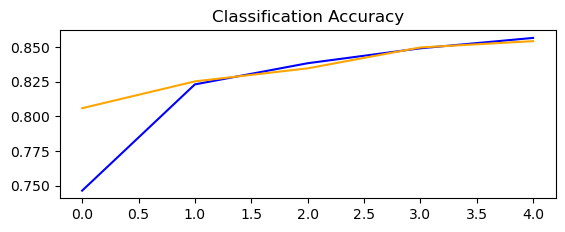

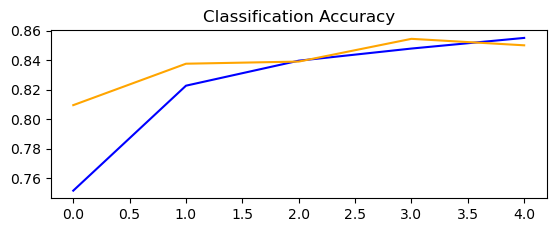

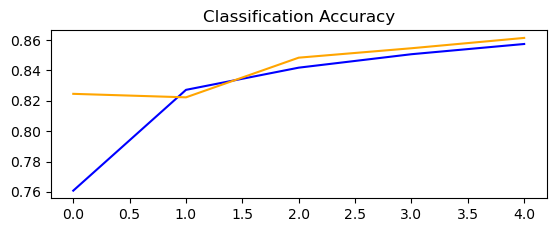

In [101]:
correr_todo()

# Tarea 2

1. Encontrar una estructura de Red Diferente[ (sin cambiar el optimizador), sólo se puede cambiar número de capas, función de activación y/o número de neuronas] que tenga un mejor Accuracy Promedio que el visto en clase para los 5 folds (85-86) fuera de la muestra. 

Si quieren pueden combinar modelos antes de la Red Neuronal(métodos de ensamble por ejemplo). El objetivo es usar una red Neuronal como última instancia. 

Por ejemplo, pueden hacer un Stacking (SVM, Árbol, Logística, KNN, etc) y en el Meta Modelo usar un Red Neuronal. 